In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from methods import ucb, thompson_sampling, etc, exp3

In [22]:
T = 100
n = 10
np.random.seed(42)
outcomes = np.zeros((n, T))
outcomes[0] = np.random.normal(0.1, 1, size=T)
for i in range(1, n):
    outcomes[i] = np.random.normal(0, 1, size=T)

exp3_returns = exp3(T, outcomes)

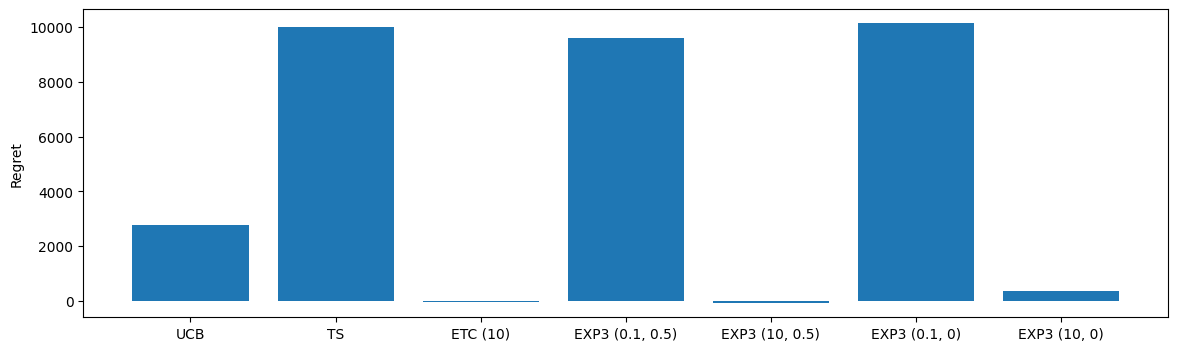

In [23]:
T = 100000
n = 10
np.random.seed(42)
outcomes = np.zeros((n, T))
outcomes[0] = np.random.normal(0.1, 1, size=T)
for i in range(1, n):
    outcomes[i] = 0.75 * (1 - 2 * np.random.binomial(1, 1/2, size=T))

ucb_returns = ucb(T, outcomes)
ts_returns = thompson_sampling(T, outcomes)
etc_returns_10 = etc(T, outcomes, m=10)
exp3_returns_sb = exp3(T, outcomes, eta=0.1, gamma=0.5)
exp3_returns_bb = exp3(T, outcomes, eta=10, gamma=0.5)
exp3_returns_ss = exp3(T, outcomes, eta=0.1, gamma=0)
exp3_returns_bs = exp3(T, outcomes, eta=10, gamma=0)

best = 0.1 * T
regrets = best - np.asarray([
    ucb_returns, ts_returns, etc_returns_10, exp3_returns_sb, exp3_returns_bb, exp3_returns_ss, exp3_returns_bs
]).sum(axis=1)
labels = ['UCB', 'TS', 'ETC (10)', 'EXP3 (0.1, 0.5)', 'EXP3 (10, 0.5)', 'EXP3 (0.1, 0)', 'EXP3 (10, 0)']

fig, ax = plt.subplots(figsize=(14,4))
plt.bar(labels, regrets)
plt.ylabel("Regret")
plt.show()

/Users/rflperry/Documents/UW/Classes/CSE_541/Interactive_learning_541/methods.py:11: RuntimeWarning: overflow encountered in exp
  arm = np.argmax(cbs)
/Users/rflperry/Documents/UW/Classes/CSE_541/Interactive_learning_541/methods.py:11: RuntimeWarning: invalid value encountered in scalar multiply
  arm = np.argmax(cbs)


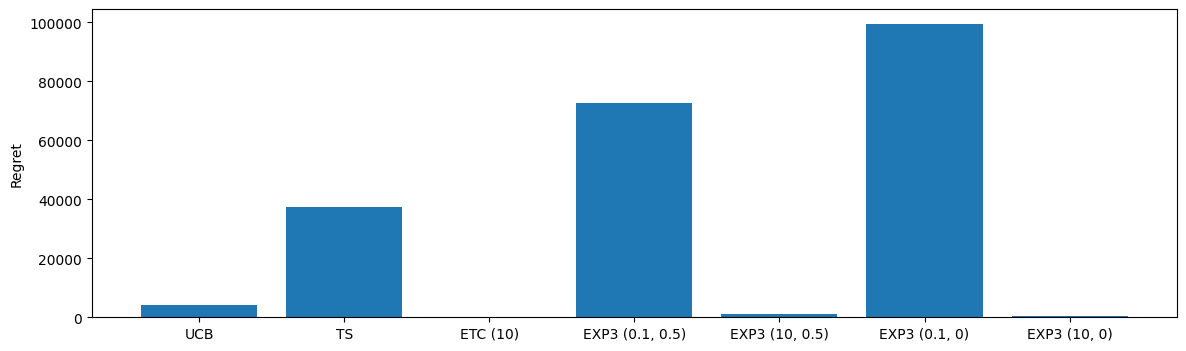

In [24]:
T = 100000
n = 40
np.random.seed(42)
outcomes = np.zeros((n, T))
outcomes[0] = np.random.normal(1, 1, size=T)
for i in range(1, n):
    outcomes[i] = 0.75 * (1 - 2 * np.random.binomial(1, (1 / np.sqrt(i)) / 2, size=T))

ucb_returns = ucb(T, outcomes)
ts_returns = thompson_sampling(T, outcomes)
etc_returns_10 = etc(T, outcomes, m=10)
exp3_returns_sb = exp3(T, outcomes, eta=0.1, gamma=0.5)
exp3_returns_bb = exp3(T, outcomes, eta=10, gamma=0.5)
exp3_returns_ss = exp3(T, outcomes, eta=0.1, gamma=0)
exp3_returns_bs = exp3(T, outcomes, eta=10, gamma=0)

best = 1 * T
regrets = best - np.asarray([
    ucb_returns, ts_returns, etc_returns_10, exp3_returns_sb, exp3_returns_bb, exp3_returns_ss, exp3_returns_bs
]).sum(axis=1)
labels = ['UCB', 'TS', 'ETC (10)', 'EXP3 (0.1, 0.5)', 'EXP3 (10, 0.5)', 'EXP3 (0.1, 0)', 'EXP3 (10, 0)']

fig, ax = plt.subplots(figsize=(14,4))
plt.bar(labels, regrets)
plt.ylabel("Regret")
plt.show()

## Problem 4

In [2]:
import urllib.request
import gzip
import numpy as np

def load_mnist():
    base_url = "https://storage.googleapis.com/cvdf-datasets/mnist/"
    files = {
        "X_train": "train-images-idx3-ubyte.gz",
        "y_train": "train-labels-idx1-ubyte.gz",
    }

    def download_and_parse(filename, is_images):
        url = base_url + filename
        with urllib.request.urlopen(url) as response:
            data = gzip.decompress(response.read())
        if is_images:
            # Offset 16: magic number (4), num images (4), rows (4), cols (4)
            return np.frombuffer(data, dtype=np.uint8, offset=16).reshape(-1, 28, 28)
        else:
            # Offset 8: magic number (4), num labels (4)
            return np.frombuffer(data, dtype=np.uint8, offset=8)

    X_train = download_and_parse(files["X_train"], is_images=True)
    y_train = download_and_parse(files["y_train"], is_images=False)

    return X_train / 255.0, y_train

X_train, y = load_mnist()

In [4]:
X = X_train.reshape(-1, 784)

In [31]:
X /= np.linalg.norm(X, axis=1).reshape(-1, 1)
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
U = pca.fit_transform(X)


In [80]:
from contextual_methods import etc_linear, etc_bias_linear, ftl_linear, linUCB, ts_linear

In [8]:
reward_func = lambda t, a: y[t] == np.argmax(a)

In [ ]:
d = 5
tau = 1000
etc_rewards = etc_linear(U[:, :d], reward_func, action_set=np.eye(10), tau=tau)
etc_bias_rewards = etc_bias_linear(U[:, :d], reward_func, action_set=np.eye(10), tau=tau)
ftl_rewards = ftl_linear(U[:, :d], reward_func, action_set=np.eye(10), tau=tau)
ucb_rewards = linUCB(U[:, :d], reward_func, action_set=np.eye(10), gamma=1)
ts_rewards = ts_linear(U[:, :d], reward_func, action_set=np.eye(10), gamma=1)

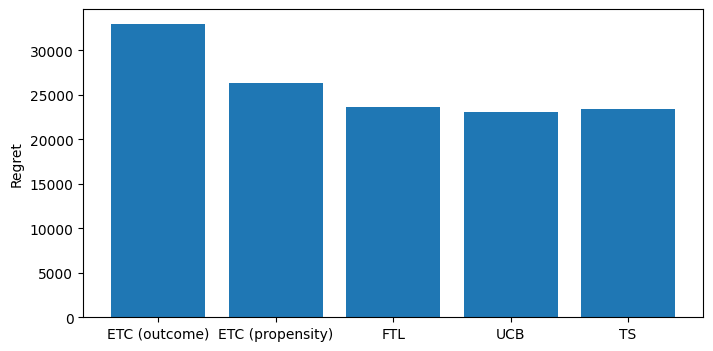

In [95]:
regrets = X.shape[0] - np.asarray([
    etc_rewards, etc_bias_rewards, ftl_rewards, ucb_rewards, ts_rewards
]).sum(1)
labels = ['ETC (outcome)', 'ETC (propensity)', 'FTL', 'UCB', 'TS']

fig, ax = plt.subplots(figsize=(8,4))
plt.bar(labels, regrets)
plt.ylabel("Regret")
plt.show()